# OpenMP Loop Grid Search Analysis

This notebook loads the averaged results from `hashjoin_omp_loop.csv` and analyzes only the loop-based OpenMP implementation. The plots are scoped to `omp_loop` so the selected parameters can be reduced independently from the task implementation.


In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

EXEC_TYPE = "omp_loop"
CSV_FILE = "hashjoin_omp_loop.csv"
ANALYSIS_LABEL = "OpenMP loop"

RESULTS_CANDIDATES = [
    Path("results"),
    Path("src/results"),
    Path("../results"),
]
IMG_CANDIDATES = [
    Path("img/omp_statistics"),
    Path("src/img/omp_statistics"),
    Path("../img/omp_statistics"),
]

RESULTS_DIR = None
csv_path = None
for candidate_dir in RESULTS_CANDIDATES:
    candidate_path = candidate_dir / CSV_FILE
    if candidate_path.exists():
        RESULTS_DIR = candidate_dir
        csv_path = candidate_path
        break

if csv_path is None:
    searched = ", ".join(str(candidate / CSV_FILE) for candidate in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"Could not find {CSV_FILE}. Searched: {searched}")

raw_df = pd.read_csv(csv_path)
raw_df["exec_type"] = EXEC_TYPE

# Keep schedule columns as strings; converting them to numeric would turn "static"/"dynamic" into NaN.
numeric_columns = [
    "checksum1",
    "checksum2",
    "join_count",
    "join_threads",
    "join_throughput",
    "join_time",
    "join_task_grain",
    "max_key",
    "nr",
    "ns",
    "offset_task_grain",
    "partition_block_size",
    "partition_chunk",
    "partition_task_grain",
    "partition_threads",
    "partition_throughput",
    "time_sec",
    "total_throughput",
    "join_chunk",
    "partition_time",
]
for col in numeric_columns:
    if col in raw_df.columns:
        raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

fallback_total_throughput = (raw_df["nr"] + raw_df["ns"]) / raw_df["time_sec"].where(raw_df["time_sec"] > 0)
if "total_throughput" not in raw_df.columns:
    raw_df["total_throughput"] = fallback_total_throughput
else:
    raw_df["total_throughput"] = raw_df["total_throughput"].fillna(fallback_total_throughput)

parameter_columns = [
    "exec_type",
    "nr",
    "ns",
    "max_key",
    "partition_threads",
    "join_threads",
    "partition_schedule",
    "join_schedule",
    "partition_chunk",
    "join_chunk",
    "partition_block_size",
    "partition_task_grain",
    "join_task_grain",
    "offset_task_grain",
]
parameter_columns = [col for col in parameter_columns if col in raw_df.columns]

validation_columns = [col for col in ["checksum1", "checksum2", "join_count"] if col in raw_df.columns]
group_columns = validation_columns + parameter_columns
metric_columns = [
    col for col in raw_df.columns
    if col not in group_columns and pd.api.types.is_numeric_dtype(raw_df[col])
]

avg_df = (
    raw_df.groupby(group_columns, as_index=False, dropna=False)
    .agg({col: "mean" for col in metric_columns})
    .sort_values("time_sec")
    .reset_index(drop=True)
)
metric = "time_sec"

for candidate in IMG_CANDIDATES:
    if candidate.parent.exists() or candidate.exists():
        IMG_DIR = candidate
        break
else:
    IMG_DIR = Path("img/omp_statistics")
IMG_DIR.mkdir(parents=True, exist_ok=True)

plot_counter = 0

def slugify(value):
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    return cleaned[:180] if cleaned else "plot"


def save_figure(fig, name):
    global plot_counter
    plot_counter += 1
    output_path = IMG_DIR / f"{plot_counter:02d}_{slugify(name)}.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"[saved] {output_path}")
    return output_path


def finish_plot(fig, name):
    output_path = save_figure(fig, name)
    display(Image(filename=str(output_path)))
    plt.close(fig)

print(f"[Loaded {raw_df.shape[0]} raw {EXEC_TYPE} rows from {csv_path}]")
print(f"[Averaged to {avg_df.shape[0]} {EXEC_TYPE} parameter combinations]")
print(f"image_output_dir: {IMG_DIR}")

summary_df = pd.DataFrame([{
    "exec_type": EXEC_TYPE,
    "combinations": len(avg_df),
    "best_time_sec": avg_df["time_sec"].min(),
    "median_time_sec": avg_df["time_sec"].median(),
    "best_total_throughput": avg_df["total_throughput"].max(),
}])
display(summary_df)


[Loaded 32 raw omp_loop rows from results/hashjoin_omp_loop.csv]
[Averaged to 32 omp_loop parameter combinations]
image_output_dir: img/omp_statistics


,exec_type,combinations,best_time_sec,median_time_sec,best_total_throughput
0,omp_loop,32,0.115816,0.119923,1.726882e+08


## Best Configurations

This table shows the best averaged configurations inside this OpenMP implementation. It is useful for choosing a smaller follow-up grid.


In [2]:
top_n = 20
config_columns = [
    "exec_type",
    "time_sec",
    "partition_time",
    "join_time",
    "total_throughput",
    "partition_threads",
    "join_threads",
    "partition_schedule",
    "join_schedule",
    "partition_chunk",
    "join_chunk",
    "partition_block_size",
    "partition_task_grain",
    "join_task_grain",
    "offset_task_grain",
]
config_columns = [col for col in config_columns if col in avg_df.columns]
relevant_columns = [col for col in config_columns if col == "exec_type" or avg_df[col].notna().any()]

print(f"Best {top_n} configurations for {EXEC_TYPE}")
display(
    avg_df
    .sort_values("time_sec")
    [relevant_columns]
    .head(top_n)
    .reset_index(drop=True)
)


Best 20 configurations for omp_loop


,exec_type,time_sec,partition_time,join_time,total_throughput,partition_threads,join_threads,partition_schedule,join_schedule,partition_chunk,join_chunk,partition_block_size
0,omp_loop,0.115816,0.077838,0.036981,1.726882e+08,32,32,guided,guided,0,0,32768
1,omp_loop,0.116194,0.078409,0.037041,1.721261e+08,32,32,guided,guided,0,8,32768
2,omp_loop,0.116655,0.078908,0.036731,1.714450e+08,32,32,guided,static,0,0,32768
3,omp_loop,0.116902,0.079093,0.037083,1.710829e+08,32,32,static,guided,0,0,16384
4,omp_loop,0.116977,0.079289,0.036649,1.709738e+08,32,32,static,static,0,0,32768
5,omp_loop,0.116997,0.078664,0.037298,1.709448e+08,32,32,static,static,0,8,32768
6,omp_loop,0.117073,0.079014,0.037024,1.708339e+08,32,32,guided,static,0,8,16384
7,omp_loop,0.117541,0.079597,0.036927,1.701532e+08,32,32,static,guided,0,8,32768
8,omp_loop,0.117660,0.079256,0.037354,1.699807e+08,32,32,guided,static,0,8,32768
9,omp_loop,0.117903,0.079976,0.037188,1.696316e+08,32,32,static,static,0,0,16384


## Thread Grid

The heatmap shows the best averaged time achievable for a `(partition_threads, join_threads)` pair after minimizing over the remaining parameters for this execution type.


[saved] img/omp_statistics/01_omp_loop_best_time_thread_heatmap.png


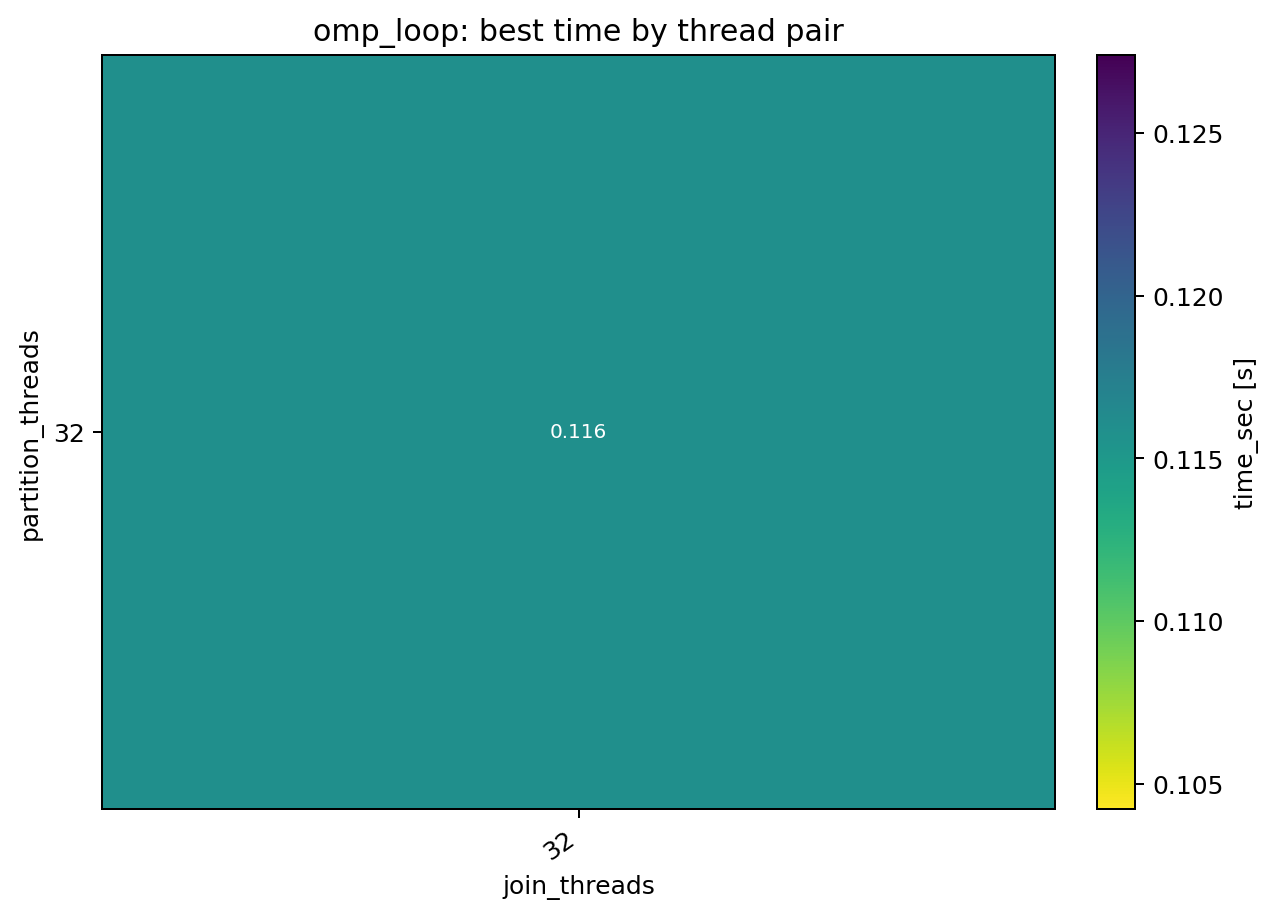

In [3]:
def format_axis_value(value):
    if pd.isna(value):
        return "NA"
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    return str(value)


def heatmap_from_table(ax, table, title, cbar_label="time_sec [s]", cmap="viridis_r"):
    image = ax.imshow(table.values, aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels([format_axis_value(v) for v in table.columns], rotation=35, ha="right")
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels([format_axis_value(v) for v in table.index])

    finite_values = pd.Series(table.to_numpy().ravel()).dropna()
    threshold = finite_values.min() * 1.05 if not finite_values.empty else None
    for row_idx, row_value in enumerate(table.index):
        for col_idx, col_value in enumerate(table.columns):
            value = table.loc[row_value, col_value]
            if pd.notna(value):
                text_color = "white" if threshold is not None and value <= threshold else "black"
                ax.text(col_idx, row_idx, f"{value:.3f}", ha="center", va="center", fontsize=8, color=text_color)

    cbar = ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)


table = avg_df.pivot_table(
    index="partition_threads",
    columns="join_threads",
    values="time_sec",
    aggfunc="min",
).sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
heatmap_from_table(ax, table, f"{EXEC_TYPE}: best time by thread pair")
ax.set_xlabel("join_threads")
ax.set_ylabel("partition_threads")
fig.tight_layout()
finish_plot(fig, f"{EXEC_TYPE}_best_time_thread_heatmap")


## Parameter Sensitivity

For each parameter value, bars show the median averaged runtime across the rest of the grid and dots show the best runtime found with that value. Lower and flatter values are safer candidates for a reduced grid.


[saved] img/omp_statistics/02_omp_loop_parameter_sensitivity.png


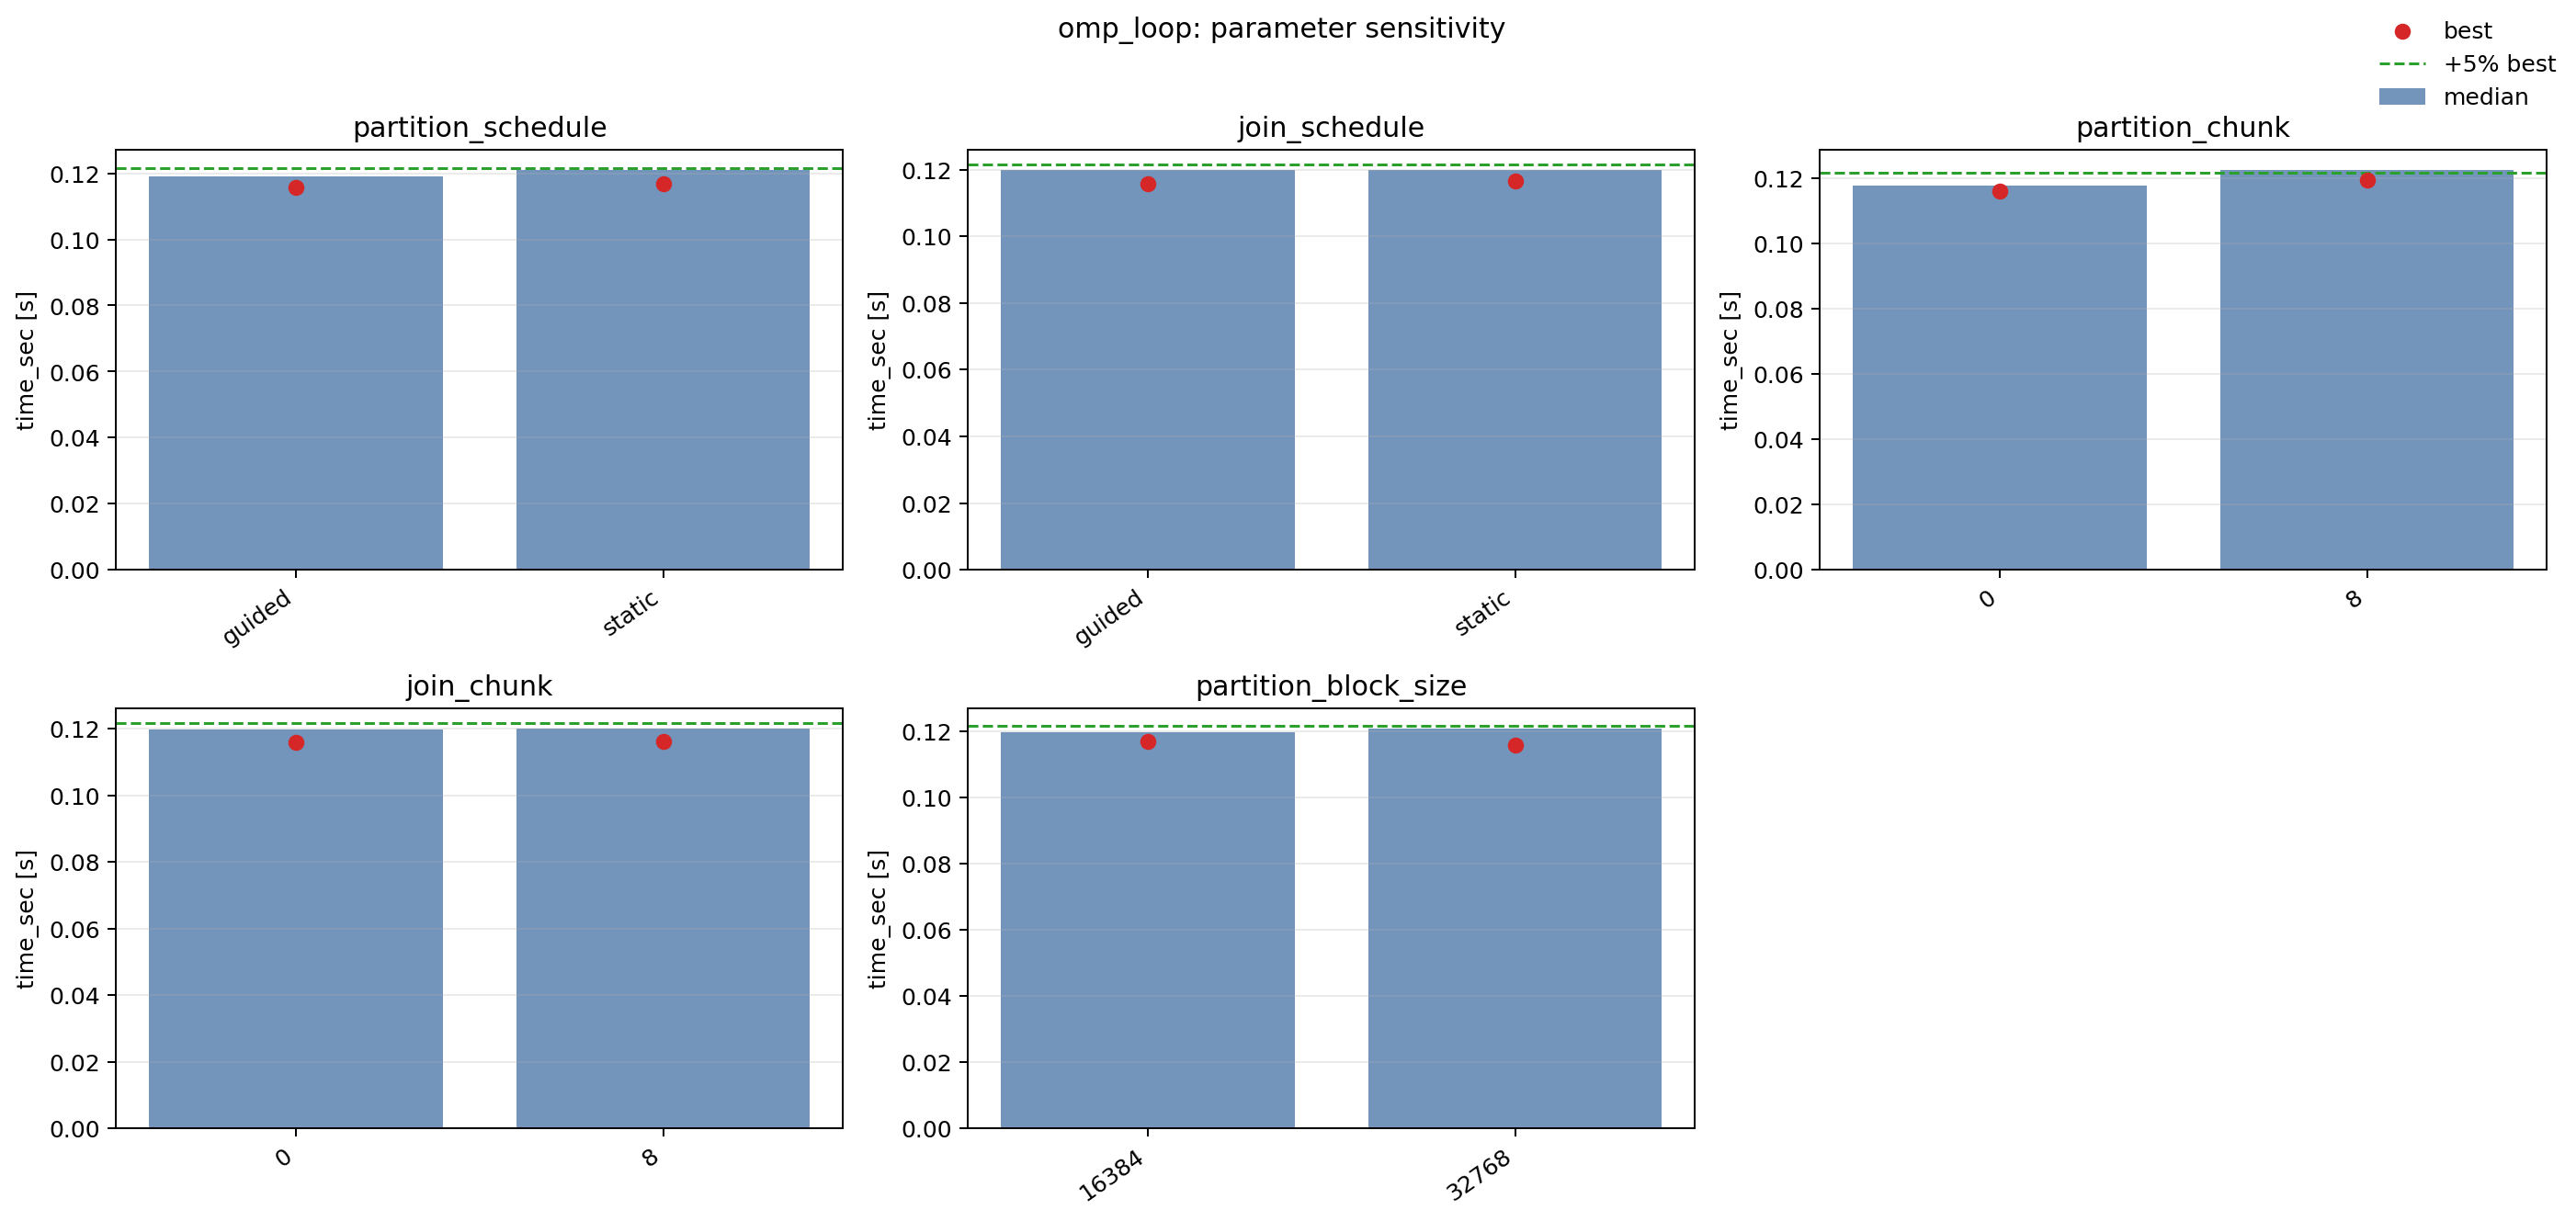

In [4]:
base_parameters = [
    "partition_threads",
    "join_threads",
    "partition_schedule",
    "join_schedule",
    "partition_chunk",
    "join_chunk",
    "partition_block_size",
    "partition_task_grain",
    "join_task_grain",
]
params = [col for col in base_parameters if col in avg_df.columns and avg_df[col].nunique(dropna=True) > 1]

if params:
    ncols = 3
    nrows = (len(params) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), squeeze=False)
    best_time = avg_df["time_sec"].min()

    for ax, param in zip(axes.ravel(), params):
        param_df = (
            avg_df.groupby(param, dropna=False)
            .agg(median_time=("time_sec", "median"), best_time=("time_sec", "min"), count=("time_sec", "size"))
            .reset_index()
            .sort_values("median_time")
        )
        x_positions = range(len(param_df))
        labels = [format_axis_value(v) for v in param_df[param]]
        ax.bar(x_positions, param_df["median_time"], color="#4C78A8", alpha=0.78, label="median")
        ax.scatter(x_positions, param_df["best_time"], color="#D62728", zorder=3, label="best")
        ax.axhline(best_time * 1.05, color="#2CA02C", linestyle="--", linewidth=1.2, label="+5% best")
        ax.set_title(param)
        ax.set_xticks(list(x_positions))
        ax.set_xticklabels(labels, rotation=35, ha="right")
        ax.set_ylabel("time_sec [s]")
        ax.grid(axis="y", alpha=0.25)

    for ax in axes.ravel()[len(params):]:
        ax.axis("off")

    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)
    fig.suptitle(f"{EXEC_TYPE}: parameter sensitivity", y=1.02)
    fig.tight_layout()
    finish_plot(fig, f"{EXEC_TYPE}_parameter_sensitivity")
else:
    print("No varying parameters available for sensitivity analysis.")


## Parameter Pair Heatmaps

These plots expose interactions that matter for reducing the grid: schedule pair, chunk pair, block size vs partition threads, and task grain pair where available.


[saved] img/omp_statistics/03_omp_loop_parameter_pair_heatmaps.png


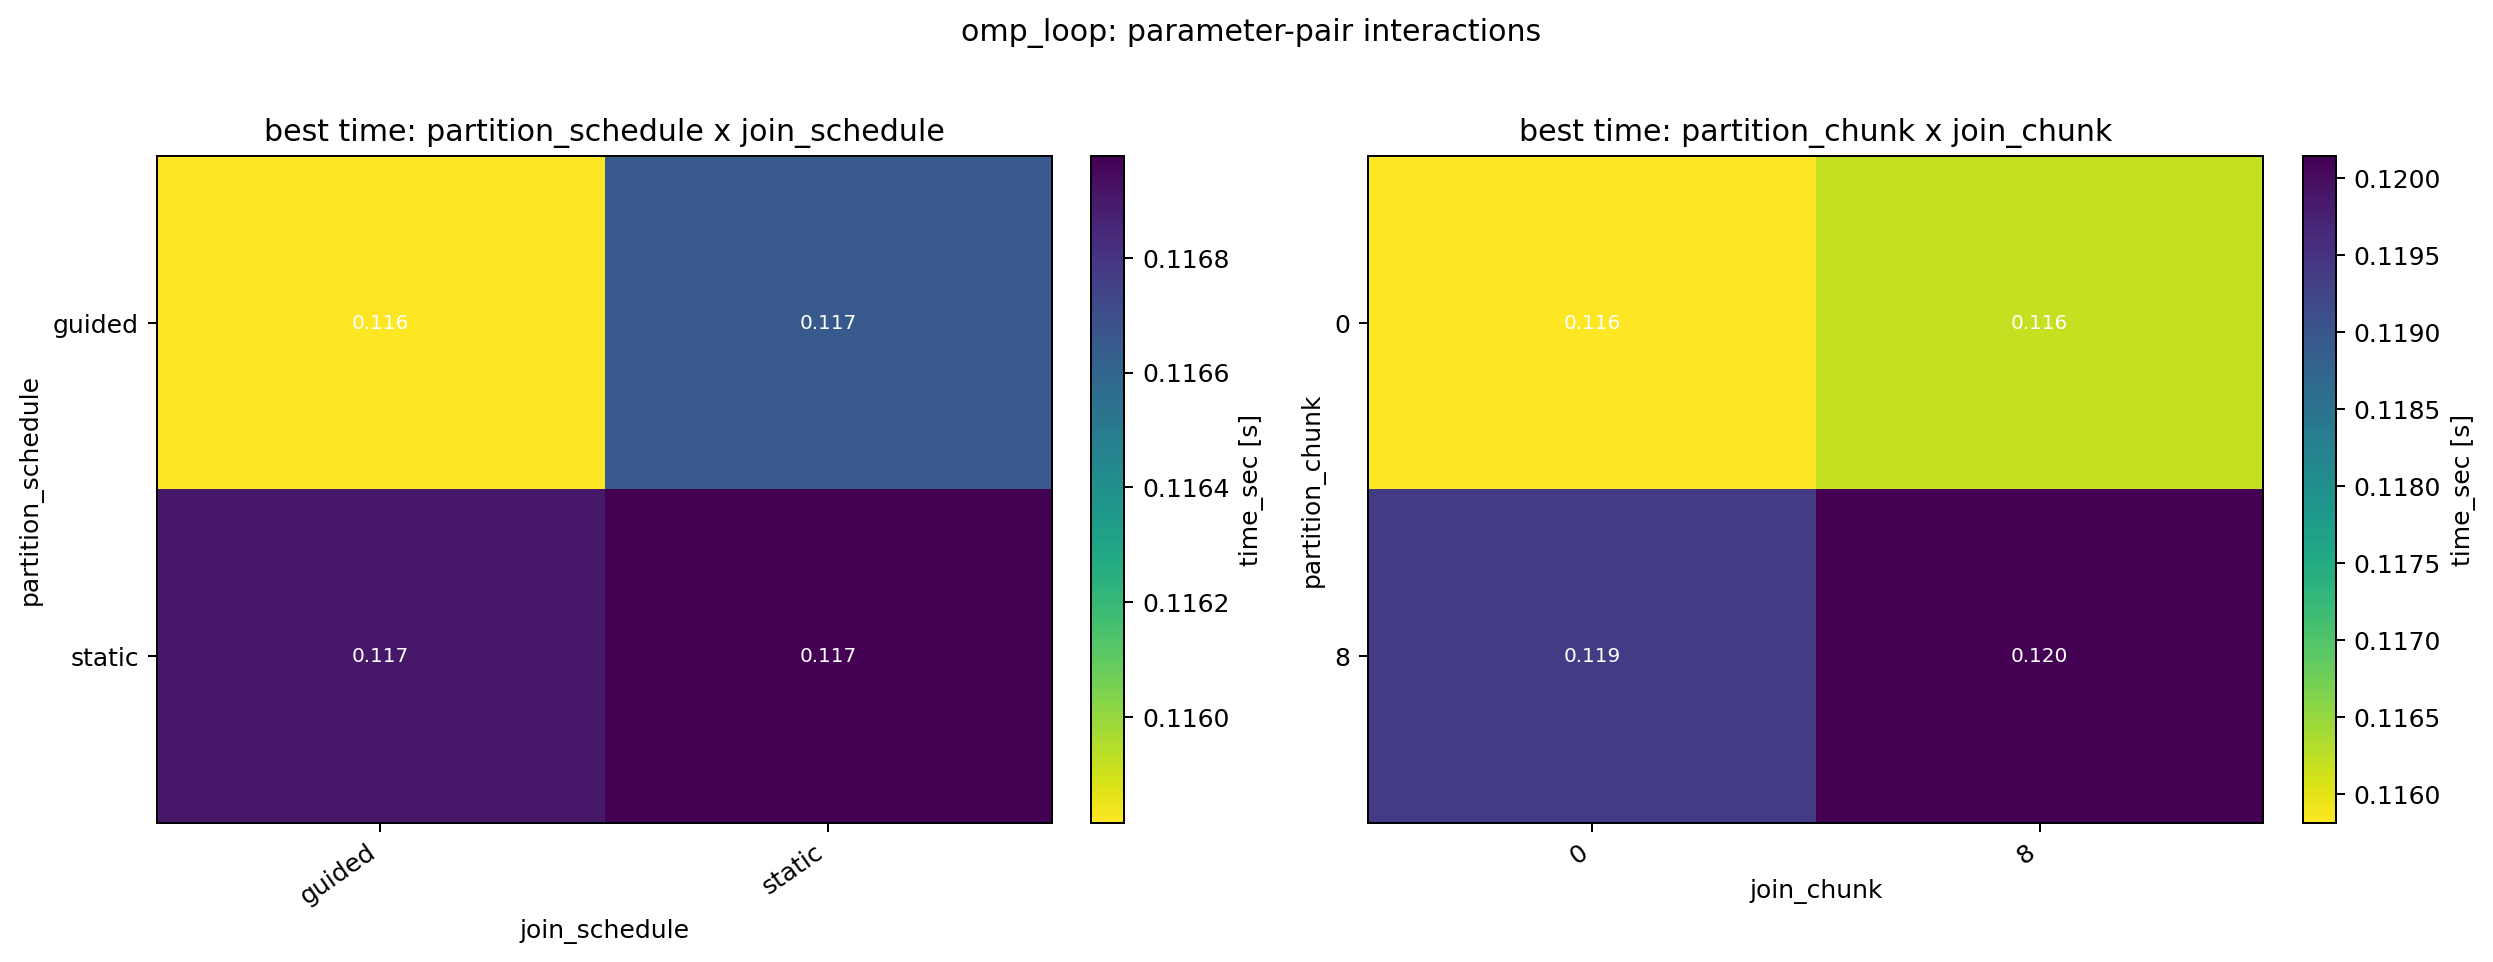

In [5]:
pair_candidates = [
    ("partition_schedule", "join_schedule"),
    ("partition_chunk", "join_chunk"),
    ("partition_block_size", "partition_threads"),
    ("partition_task_grain", "join_task_grain"),
]
pairs = [
    (row_col, col_col)
    for row_col, col_col in pair_candidates
    if row_col in avg_df.columns
    and col_col in avg_df.columns
    and avg_df[row_col].nunique(dropna=True) > 1
    and avg_df[col_col].nunique(dropna=True) > 1
]

if pairs:
    ncols = 2
    nrows = (len(pairs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.0 * ncols, 5.2 * nrows), squeeze=False)

    for ax, (row_col, col_col) in zip(axes.ravel(), pairs):
        table = avg_df.pivot_table(index=row_col, columns=col_col, values="time_sec", aggfunc="min")
        table = table.sort_index().sort_index(axis=1)
        heatmap_from_table(ax, table, f"best time: {row_col} x {col_col}")
        ax.set_xlabel(col_col)
        ax.set_ylabel(row_col)

    for ax in axes.ravel()[len(pairs):]:
        ax.axis("off")

    fig.suptitle(f"{EXEC_TYPE}: parameter-pair interactions", y=1.02)
    fig.tight_layout()
    finish_plot(fig, f"{EXEC_TYPE}_parameter_pair_heatmaps")
else:
    print("No varying parameter pairs available for heatmap analysis.")


## Reduced Grid Candidates

This table marks parameter values that appear in configurations within 5% and 10% of the best averaged runtime for this execution type.


In [6]:
rows = []
for param in params:
    best_time = avg_df["time_sec"].min()
    for tolerance in [0.05, 0.10]:
        near_best = avg_df[avg_df["time_sec"] <= best_time * (1.0 + tolerance)]
        values = near_best[param].dropna().unique().tolist()
        values = sorted(values)
        rows.append({
            "exec_type": EXEC_TYPE,
            "parameter": param,
            "threshold": f"within {int(tolerance * 100)}%",
            "candidate_values": ", ".join(format_axis_value(v) for v in values),
            "n_values": len(values),
            "n_configs": len(near_best),
        })

candidate_values_df = pd.DataFrame(rows)
display(candidate_values_df)


,exec_type,parameter,threshold,candidate_values,n_values,n_configs
0,omp_loop,partition_schedule,within 5%,"guided, static",2,22
1,omp_loop,partition_schedule,within 10%,"guided, static",2,29
2,omp_loop,join_schedule,within 5%,"guided, static",2,22
3,omp_loop,join_schedule,within 10%,"guided, static",2,29
4,omp_loop,partition_chunk,within 5%,"0, 8",2,22
5,omp_loop,partition_chunk,within 10%,"0, 8",2,29
6,omp_loop,join_chunk,within 5%,"0, 8",2,22
7,omp_loop,join_chunk,within 10%,"0, 8",2,29
8,omp_loop,partition_block_size,within 5%,"16384, 32768",2,22
9,omp_loop,partition_block_size,within 10%,"16384, 32768",2,29
